In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive')


['Colab Notebooks',
 'WhatsApp Image 2025-11-23 at 6.04.23 PM.jpeg',
 'REEMFAIZlardhi-CV.pdf',
 'معايير اعتماد جهة تدريب هندسة البرمجيات (1) (3) (1).pdf',
 'Cv Reem faiz',
 'dataset',
 'im',
 'https:  kkeshme.txt',
 'dataset_split',
 'archive']

In [ ]:
path = '/content/drive/MyDrive/archive'
os.listdir(path)


['pause_sign.csv',
 'sensors_data_1.csv',
 'sensors_data_3.csv',
 'sensors_data_2.csv',
 'sensor_data_4.csv']

In [ ]:
import pandas as pd
import os

files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')]

df_list = []

for f in files:
    temp = pd.read_csv(f)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("Shape:", df.shape)
df.head()


Shape: (2590, 441)


,Flex-Left-1-Frame-1,Flex-Left-1-Frame-2,Flex-Left-1-Frame-3,Flex-Left-1-Frame-4,Flex-Left-1-Frame-5,Flex-Left-1-Frame-6,Flex-Left-1-Frame-7,Flex-Left-1-Frame-8,Flex-Left-1-Frame-9,Flex-Left-1-Frame-10,...,Orientation-X-Right-Frame-18,Orientation-Y-Right-Frame-18,Orientation-Z-Right-Frame-18,Orientation-X-Right-Frame-19,Orientation-Y-Right-Frame-19,Orientation-Z-Right-Frame-19,Orientation-X-Right-Frame-20,Orientation-Y-Right-Frame-20,Orientation-Z-Right-Frame-20,SIGN
0,187,184,187,186,184,184,186,189,190,187,...,0.00,0.04,0.16,0.00,0.03,0.15,0.02,0.04,0.17,PAUSE
1,189,186,189,189,187,190,190,189,189,189,...,0.01,0.04,0.16,0.01,0.04,0.15,0.01,0.04,0.15,PAUSE
2,187,190,189,189,186,189,189,187,189,190,...,0.01,0.04,0.15,0.00,0.04,0.15,0.01,0.04,0.15,PAUSE
3,175,174,174,175,175,175,174,175,175,174,...,0.00,0.04,0.16,0.01,0.03,0.16,0.01,0.03,0.16,PAUSE
4,178,177,175,178,174,178,175,178,177,177,...,0.01,0.04,0.16,0.01,0.04,0.16,0.01,0.04,0.15,PAUSE


In [ ]:
import re
import numpy as np

label_col = "SIGN"

# استخراج الأعمدة التي تحتوي Frame
frame_cols = [c for c in df.columns if "Frame-" in c]

# استخراج أرقام الفريمات
frames = sorted({int(re.search(r"Frame-(\d+)", c).group(1)) for c in frame_cols})

X_list = []

for f in frames:
    cols_f = [c for c in frame_cols if c.endswith(f"Frame-{f}")]
    cols_f = sorted(cols_f)
    X_list.append(df[cols_f].to_numpy())

# تحويلها إلى (samples, time_steps, features)
X = np.stack(X_list, axis=1)

y = df[label_col].values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2590, 20, 22)
y shape: (2590,)


In [ ]:
import pandas as pd

# 1) احذف الصفوف اللي SIGN فيها فاضي (NaN)
df = df.dropna(subset=['SIGN']).copy()

# 2) نظّفي النص (تشيل الفراغات)
df['SIGN'] = df['SIGN'].astype(str).str.strip()

# 3) احذف أي كلاس عددها أقل من 2 (عشان stratify ما يعلق)
counts = df['SIGN'].value_counts()
df = df[df['SIGN'].isin(counts[counts >= 2].index)].copy()

print("After cleaning df:", df.shape)
print(df['SIGN'].value_counts())



After cleaning df: (2589, 441)
SIGN
THANK YOU    399
THIS         399
PROUD        398
STUDENT      397
WE           397
PAUSE        300
WORK         299
Name: count, dtype: int64


In [ ]:
import re
import numpy as np

label_col = "SIGN"

# كل الأعمدة اللي فيها Frame-
frame_cols = [c for c in df.columns if "Frame-" in c]

# أرقام الفريمات
frames = sorted({int(re.search(r"Frame-(\d+)", c).group(1)) for c in frame_cols})

# بناء X: (samples, time_steps, features)
X_list = []
for f in frames:
    cols_f = sorted([c for c in frame_cols if c.endswith(f"Frame-{f}")])
    X_list.append(df[cols_f].to_numpy())

X = np.stack(X_list, axis=1)
y = df[label_col].values

print("X shape:", X.shape)  # لازم تطلع (شي, 20, 22)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))


X shape: (2589, 20, 22)
y shape: (2589,)
Unique labels: ['PAUSE' 'PROUD' 'STUDENT' 'THANK YOU' 'THIS' 'WE' 'WORK']


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode labels
le = LabelEncoder()
y_int = le.fit_transform(y)
num_classes = len(le.classes_)
print("Classes:", le.classes_)

# Train/test split (مع stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_int, test_size=0.2, random_state=42, stratify=y_int
)

print("Train:", X_train.shape, "Test:", X_test.shape)

# Scaling
scaler = StandardScaler()
N, T, F = X_train.shape

X_train_2d = X_train.reshape(-1, F)
X_test_2d  = X_test.reshape(-1, F)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(N, T, F)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape[0], T, F)

print("Scaled train:", X_train_scaled.shape, "Scaled test:", X_test_scaled.shape)


Classes: ['PAUSE' 'PROUD' 'STUDENT' 'THANK YOU' 'THIS' 'WE' 'WORK']
Train: (2071, 20, 22) Test: (518, 20, 22)
Scaled train: (2071, 20, 22) Scaled test: (518, 20, 22)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(le.classes_)   # عندك 7

model = models.Sequential([
    layers.Input(shape=(20, 22)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(32),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
]

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,255 (145.53 KB)

 Trainable params: 37,255 (145.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.3761 - loss: 1.7791 - val_accuracy: 0.9398 - val_loss: 0.9747 - learning_rate: 0.0010
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9340 - loss: 0.8250 - val_accuracy: 0.9976 - val_loss: 0.2425 - learning_rate: 0.0010
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9984 - loss: 0.2305 - val_accuracy: 0.9976 - val_loss: 0.0391 - learning_rate: 0.0010
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9992 - loss: 0.0433 - val_accuracy: 0.9976 - val_loss: 0.0226 - learning_rate: 0.0010
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9953 - loss: 0.0251 - val_accuracy: 0.9976 - val_loss: 0.0195 - learning_rate: 0.0010
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9983 - loss: 0.0163 - val_accuracy: 0.9976 - val_loss: 0.0182 - learning_rate: 0.0010
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0084 - val_acc

Test Accuracy: 1.0
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

Classification Report:
              precision    recall  f1-score   support

       PAUSE       1.00      1.00      1.00        60
       PROUD       1.00      1.00      1.00        80
     STUDENT       1.00      1.00      1.00        79
   THANK YOU       1.00      1.00      1.00        80
        THIS       1.00      1.00      1.00        80
          WE       1.00      1.00      1.00        79
        WORK       1.00      1.00      1.00        60

    accuracy                           1.00       518
   macro avg       1.00      1.00      1.00       518
weighted avg       1.00      1.00      1.00       518



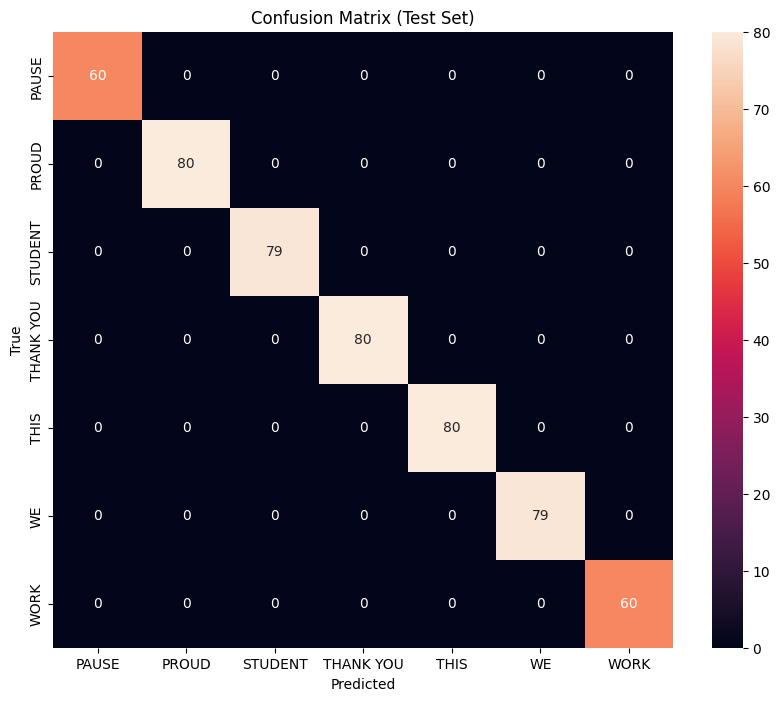

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Test Accuracy:", acc)

y_pred = np.argmax(model.predict(X_test_scaled), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()


In [ ]:
import numpy as np

# 1) خريطة التحويل
start_set = {"PROUD", "THANK YOU"}
stop_set  = {"PAUSE", "WORK"}
idle_set  = {"THIS", "WE", "STUDENT"}

def map_label(x):
    if x in start_set: return "START"
    if x in stop_set:  return "STOP"
    return "IDLE"

df_cmd = df.copy()
df_cmd["CMD"] = df_cmd["SIGN"].apply(map_label)

print(df_cmd["CMD"].value_counts())


CMD
IDLE     1193
START     797
STOP      599
Name: count, dtype: int64


In [ ]:
import re, numpy as np

label_col = "CMD"
frame_cols = [c for c in df_cmd.columns if "Frame-" in c]
frames = sorted({int(re.search(r"Frame-(\d+)", c).group(1)) for c in frame_cols})

X_list = []
for f in frames:
    cols_f = sorted([c for c in frame_cols if c.endswith(f"Frame-{f}")])
    X_list.append(df_cmd[cols_f].to_numpy())

X_cmd = np.stack(X_list, axis=1)
y_cmd = df_cmd[label_col].values

print("X_cmd:", X_cmd.shape, "y_cmd:", y_cmd.shape, "labels:", np.unique(y_cmd))


X_cmd: (2589, 20, 22) y_cmd: (2589,) labels: ['IDLE' 'START' 'STOP']


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le_cmd = LabelEncoder()
y_int = le_cmd.fit_transform(y_cmd)

X_train, X_test, y_train, y_test = train_test_split(
    X_cmd, y_int, test_size=0.2, random_state=42, stratify=y_int
)

scaler = StandardScaler()
N, T, F = X_train.shape
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, F)).reshape(N, T, F)
X_test_scaled  = scaler.transform(X_test.reshape(-1, F)).reshape(X_test.shape[0], T, F)

print("Classes:", le_cmd.classes_)


Classes: ['IDLE' 'START' 'STOP']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

num_classes = len(le_cmd.classes_)  # المفروض 3

cmd_model = models.Sequential([
    layers.Input(shape=(20, 22)),
    layers.LSTM(32, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(16),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

cmd_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = cmd_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

loss, acc = cmd_model.evaluate(X_test_scaled, y_test, verbose=0)
print("Test Accuracy:", acc)


Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6182 - loss: 1.0100 - val_accuracy: 0.9133 - val_loss: 0.6567
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9337 - loss: 0.5398 - val_accuracy: 1.0000 - val_loss: 0.2122
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9956 - loss: 0.1885 - val_accuracy: 1.0000 - val_loss: 0.0655
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9990 - loss: 0.0605 - val_accuracy: 1.0000 - val_loss: 0.0269
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9997 - loss: 0.0259 - val_accuracy: 1.0000 - val_loss: 0.0146
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9983 - loss: 0.0217 - val_accuracy: 1.0000 - val_loss: 0.0093
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9992 - loss: 0.0133 - val_accuracy: 1.0000 - val_loss: 0.0066
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9997 - loss: 0.0080 - val_accuracy: 1.0000 - v

Test Accuracy: 1.0
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

        IDLE       1.00      1.00      1.00       239
       START       1.00      1.00      1.00       159
        STOP       1.00      1.00      1.00       120

    accuracy                           1.00       518
   macro avg       1.00      1.00      1.00       518
weighted avg       1.00      1.00      1.00       518



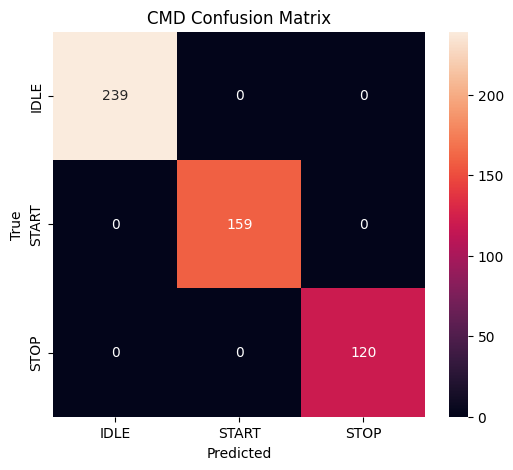

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

loss, acc = cmd_model.evaluate(X_test_scaled, y_test, verbose=0)
print("Test Accuracy:", acc)

y_pred = np.argmax(cmd_model.predict(X_test_scaled), axis=1)
print(classification_report(y_test, y_pred, target_names=le_cmd.classes_, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le_cmd.classes_, yticklabels=le_cmd.classes_)
plt.title("CMD Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
import time

sending = False
last_action_time = 0

def decide_command(probs, le, threshold=0.85):
    idx = int(np.argmax(probs))
    conf = float(np.max(probs))
    label = le.inverse_transform([idx])[0]
    if conf < threshold:
        return "NONE", conf
    return label, conf

# مثال تشغيل على 10 عينات من test
for i in range(10):
    probs = cmd_model.predict(X_test_scaled[i:i+1], verbose=0)[0]
    cmd, conf = decide_command(probs, le_cmd, threshold=0.85)

    # cooldown 1 ثانية
    now = time.time()
    if cmd in ["START","STOP"] and (now - last_action_time) < 1.0:
        cmd = "NONE"

    if cmd == "START" and not sending:
        sending = True
        last_action_time = now
        print(f"✅ START (conf={conf:.2f})")

    elif cmd == "STOP" and sending:
        sending = False
        last_action_time = now
        print(f"⛔ STOP (conf={conf:.2f})")

    else:
        print(f"- {cmd} (conf={conf:.2f}) sending={sending}")


✅ START (conf=1.00)
- NONE (conf=1.00) sending=True
- NONE (conf=1.00) sending=True
- NONE (conf=1.00) sending=True
- IDLE (conf=1.00) sending=True
- IDLE (conf=1.00) sending=True
- IDLE (conf=1.00) sending=True
- NONE (conf=1.00) sending=True
- IDLE (conf=1.00) sending=True
- NONE (conf=1.00) sending=True
